# 13.3 線形動的システムとカルマンフィルタ (Linear Dynamical Systems & Kalman Filter)

本ノートブックでは、潜在変数が連続実数ベクトルであるマルコフ動的システムである **線形動的システム (Linear Dynamical Systems: LDS)** を学びます。
離散状態を用いる隠れマルコフモデル (HMM) に対し、LDSは状態空間が連続であり、自然界の物理運動やセンサトラッキングなど、時間とともに連続的に変化する現象をモデル化するために用いられます。

## 連続潜在空間への拡張とガウス分布仮定

HMMの潜在変数 $\mathbf{z}_n$ を連続空間に拡張した場合、遷移確率や放出確率として任意の複雑な分布を許すと、周辺化のための積分が解析的に解けなくなります。しかし、すべての分布を **線形ガウスモデル (Linear Gaussian Model)** と仮定することで、事後分布も常にガウス分布に保たれ、厳密かつ効率的な推論が可能になります。これを線形動的システムと呼びます。

LDSは以下の2つの方程式（状態方程式および観測方程式）で定義されます：
$$ \mathbf{z}_n = \mathbf{A} \mathbf{z}_{n-1} + \mathbf{w}_n $$
$$ \mathbf{x}_n = \mathbf{C} \mathbf{z}_n + \mathbf{v}_n $$
ここで：
- $\mathbf{z}_n$ : 連続潜在状態ベクトル
- $\mathbf{x}_n$ : 観測データベクトル
- $\mathbf{A}$ : 状態遷移マトリクス
- $\mathbf{C}$ : 観測（放出）マトリクス
- $\mathbf{w}_n \sim \mathcal{N}(\mathbf{0}, \mathbf{\Gamma})$ : システムノイズ（共分散行列 $\mathbf{\Gamma}$）
- $\mathbf{v}_n \sim \mathcal{N}(\mathbf{0}, \mathbf{\Sigma})$ : 観測ノイズ（共分散行列 $\mathbf{\Sigma}$）

これを確率分布の形で表現すると次のようになります。状態遷移は過去の状態の線形変換を平均とするガウス分布です：
$$ p(\mathbf{z}_n | \mathbf{z}_{n-1}) = \mathcal{N}(\mathbf{z}_n | \mathbf{A}\mathbf{z}_{n-1}, \mathbf{\Gamma}) $$
観測分布も現在の状態の線形変換を平均とするガウス分布です：
$$ p(\mathbf{x}_n | \mathbf{z}_n) = \mathcal{N}(\mathbf{x}_n | \mathbf{C}\mathbf{z}_n, \mathbf{\Sigma}) $$
初期状態もまたガウス分布に従うとします：
$$ p(\mathbf{z}_1) = \mathcal{N}(\mathbf{z}_1 | \boldsymbol{\mu}_0, \mathbf{V}_0) $$

驚くべきことに、LDSとHMMはグラフィカルモデルとしては全く同一の構造を持ちます。潜在変数が離散（HMM）か連続（LDS）かという違いによって、メッセージパッシング推論のアルゴリズムが「和（$\sum$）」から「積分（$\int$）」に置き換わっただけであり、HMMの Forward-Backward アルゴリズムは、LDS における **カルマンフィルタ (Kalman Filter)** と **カルマンスムーザ (RTS Smoother)** に一対一対応します。

## 13.3.1 カルマンフィルタと不確実性のダイナミクス (PRML Figure 13.21)

カルマンフィルタは、過去から現在までの観測データ $\mathbf{x}_1, \dots, \mathbf{x}_n$ に基づいて、現在の状態 $\mathbf{z}_n$ の事後分布 $p(\mathbf{z}_n | \mathbf{x}_1, \dots, \mathbf{x}_n)$ をオンラインで逐次更新するアルゴリズムです。これは HMM の前向きアルゴリズム（$\alpha$-recursion）の連続ガウス版にあたります。

ガウス分布は平均ベクトルと共分散行列によって完全に決定されるため、フィルタリング分布もまたガウス分布になります：
$$ p(\mathbf{z}_n | \mathbf{x}_1, \dots, \mathbf{x}_n) = \mathcal{N}(\mathbf{z}_n | \boldsymbol{\mu}_n, \mathbf{V}_n) $$
この推論は **予測ステップ (Predict)** と **更新ステップ (Update)** の2段階の再帰プロセスで構成されます。

### 1. 予測ステップ (Time Update / Predict)
時刻 $n-1$ の推定値を用いて、時刻 $n$ の事前分布（観測前の状態の予測）を求めます。
$$ p(\mathbf{z}_n | \mathbf{x}_1, \dots, \mathbf{x}_{n-1}) = \mathcal{N}(\mathbf{z}_n | \boldsymbol{\mu}_{n|n-1}, \mathbf{P}_{n|n-1}) $$
状態遷移の線形性と期待値・分散の性質から、以下が導かれます：
$$ \boldsymbol{\mu}_{n|n-1} = \mathbf{A}\boldsymbol{\mu}_{n-1} $$
$$ \mathbf{P}_{n|n-1} = \mathbf{A}\mathbf{V}_{n-1}\mathbf{A}^{\mathrm{T}} + \mathbf{\Gamma} $$
システムダイナミクスに伴ってシステムノイズ $\mathbf{\Gamma}$ が加算されるため、状態の不確実性（分散楕円）は **拡散して拡大** します（PRML Figure 13.21 参照）。

### 2. 更新ステップ (Measurement Update)
新しい観測 $\mathbf{x}_n$ が得られたとき、ベイズの定理を用いて事前分布を事後分布へと更新します。
$$ \boldsymbol{\mu}_n = \boldsymbol{\mu}_{n|n-1} + \mathbf{K}_n (\mathbf{x}_n - \mathbf{C}\boldsymbol{\mu}_{n|n-1}) $$
ここで $\mathbf{K}_n$ は **カルマンゲイン (Kalman Gain)** と呼ばれる行列であり、予測誤差 $(\mathbf{x}_n - \mathbf{C}\boldsymbol{\mu}_{n|n-1})$ （イノベーション）をどれだけ信用して状態を補正するかを決定します：
$$ \mathbf{K}_n = \mathbf{P}_{n|n-1}\mathbf{C}^{\mathrm{T}} (\mathbf{C}\mathbf{P}_{n|n-1}\mathbf{C}^{\mathrm{T}} + \mathbf{\Sigma})^{-1} $$

共分散の更新は次のようになります：
$$ \mathbf{V}_n = (\mathbf{I} - \mathbf{K}_n \mathbf{C})\mathbf{P}_{n|n-1} $$
（※数値的安定性を高めるために、ジョセフ安定化形 (Joseph stabilized form) $\mathbf{V}_n = (\mathbf{I} - \mathbf{K}_n\mathbf{C})\mathbf{P}_{n|n-1}(\mathbf{I} - \mathbf{K}_n\mathbf{C})^{\mathrm{T}} + \mathbf{K}_n\mathbf{\Sigma}\mathbf{K}_n^{\mathrm{T}}$ が用いられることもあります。）

新たな観測データ $\mathbf{x}_n$ が得られることで、不確実性は補正されて分散楕円は **収縮** します。予測と更新を繰り返すことで、カルマンフィルタはノイズの乗った観測系列から滑らかな真の軌跡をオンラインで推論します。

Plot saved to: result/fig13_21_kalman_uncertainty_dynamics.png


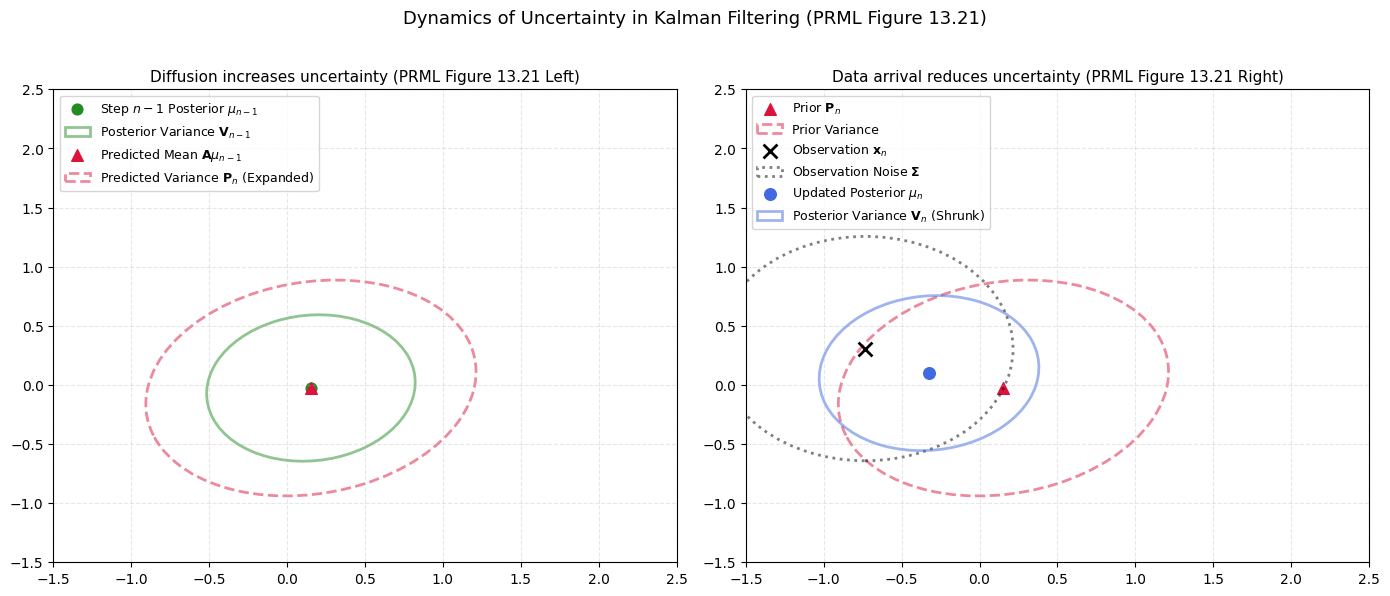

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from common.plot_utils import save_plot, setup_style
from common.sequential_utils import KalmanFilter
setup_style()

def plot_cov_ellipse(ax, mean, cov, color='blue', alpha=0.5, linestyle='-', label=None):
    vals, vecs = np.linalg.eigh(cov)
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2.0 * np.sqrt(np.maximum(vals, 1e-8)) * 1.5 # 1.5-sigma
    ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                  edgecolor=color, facecolor='none', linestyle=linestyle, lw=2.0, alpha=alpha, label=label)
    ax.add_patch(ell)

# 2次元平面上での物体追跡 LDS
# 状態 z = [pos_x, pos_y], 観測 x = [meas_x, meas_y]
A_mat = np.array([[1.0, 0.0], [0.0, 1.0]]) # ランダムウォークドリフト
C_mat = np.array([[1.0, 0.0], [0.0, 1.0]])
Gamma_mat = np.array([[0.3, 0.05], [0.05, 0.2]]) # システム拡散ノイズ
Sigma_mat = np.array([[0.4, 0.0], [0.0, 0.4]])   # 観測ノイズ

mu_0 = np.array([0.0, 0.0])
V_0 = np.array([[0.1, 0.0], [0.0, 0.1]])

# 3ステップの追跡過程 (PRML Figure 13.21)
# ステップ 1: 事後 -> ステップ 2: 予測 (拡散拡大) -> 観測到着 -> 事後 (収縮)
np.random.seed(42)
z_true = [mu_0]
x_obs = [z_true[0] + np.random.multivariate_normal([0, 0], Sigma_mat)]

for _ in range(4):
    z_next = A_mat @ z_true[-1] + np.random.multivariate_normal([0, 0], Gamma_mat)
    x_next = C_mat @ z_next + np.random.multivariate_normal([0, 0], Sigma_mat)
    z_true.append(z_next)
    x_obs.append(x_next)

z_true = np.array(z_true)
x_obs = np.array(x_obs)

# カルマンフィルタの実行
kf = KalmanFilter(A_mat, C_mat, Gamma_mat, Sigma_mat, mu_0, V_0)
mu_filt, V_filt = kf.filter(x_obs)

# PRML Figure 13.21 のプロット: 予測楕円 (拡散) と 更新楕円 (収縮)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))

# (a) 予測ステップでの拡散による不確実性の増大
axes[0].scatter(mu_filt[0, 0], mu_filt[0, 1], color='forestgreen', s=60, label=r'Step $n-1$ Posterior $\mu_{n-1}$')
plot_cov_ellipse(axes[0], mu_filt[0], V_filt[0], color='forestgreen', linestyle='-', label=r'Posterior Variance $\mathbf{V}_{n-1}$')

# 予測分散 P_n = A V A^T + Gamma
P_pred = A_mat @ V_filt[0] @ A_mat.T + Gamma_mat
mu_pred = A_mat @ mu_filt[0]
axes[0].scatter(mu_pred[0], mu_pred[1], color='crimson', marker='^', s=70, label=r'Predicted Mean $\mathbf{A}\mu_{n-1}$')
plot_cov_ellipse(axes[0], mu_pred, P_pred, color='crimson', linestyle='--', label=r'Predicted Variance $\mathbf{P}_n$ (Expanded)')

axes[0].set_title('Diffusion increases uncertainty (PRML Figure 13.21 Left)', fontsize=11)
axes[0].set_xlim(-1.5, 2.5); axes[0].set_ylim(-1.5, 2.5)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, linestyle='--', alpha=0.3)

# (b) 観測データ到着による不確実性の収縮
axes[1].scatter(mu_pred[0], mu_pred[1], color='crimson', marker='^', s=70, label=r'Prior $\mathbf{P}_n$')
plot_cov_ellipse(axes[1], mu_pred, P_pred, color='crimson', linestyle='--', label='Prior Variance')

axes[1].scatter(x_obs[1, 0], x_obs[1, 1], color='black', marker='x', s=100, lw=2, label=r'Observation $\mathbf{x}_n$')
plot_cov_ellipse(axes[1], x_obs[1], Sigma_mat, color='black', linestyle=':', label=r'Observation Noise $\mathbf{\Sigma}$')

axes[1].scatter(mu_filt[1, 0], mu_filt[1, 1], color='royalblue', s=70, label=r'Updated Posterior $\mu_n$')
plot_cov_ellipse(axes[1], mu_filt[1], V_filt[1], color='royalblue', linestyle='-', label=r'Posterior Variance $\mathbf{V}_n$ (Shrunk)')

axes[1].set_title('Data arrival reduces uncertainty (PRML Figure 13.21 Right)', fontsize=11)
axes[1].set_xlim(-1.5, 2.5); axes[1].set_ylim(-1.5, 2.5)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Dynamics of Uncertainty in Kalman Filtering (PRML Figure 13.21)', fontsize=13, y=1.02)
plt.tight_layout()
save_plot(fig, 'result', 'fig13_21_kalman_uncertainty_dynamics.png')
plt.show()

## カルマンフィルタ vs カルマンスムーザ (RTS) の軌跡平滑化比較

カルマンフィルタは過去から現在までの観測のみを利用しますが、時系列の事後解析を行う場合、全観測系列 $\mathbf{x}_1, \dots, \mathbf{x}_N$ を利用して各時刻の状態の事後分布 $p(\mathbf{z}_n | \mathbf{x}_1, \dots, \mathbf{x}_N)$ を求めることができ、これを **平滑化 (Smoothing)** と呼びます。HMM における後ろ向きアルゴリズム（$\beta$-recursion）の連続版に相当するのが **カルマンスムーザ (Rauch-Tung-Striebel Smoother: RTS)** です。

RTSスムーザは、前向きのカルマンフィルタを系列の終端 $N$ まで実行した後、後ろ向きに再帰的に平均と共分散を更新していきます。平滑化分布もまたガウス分布になります：
$$ p(\mathbf{z}_n | \mathbf{x}_1, \dots, \mathbf{x}_N) = \mathcal{N}(\mathbf{z}_n | \hat{\boldsymbol{\mu}}_n, \hat{\mathbf{V}}_n) $$

### RTS スムーザの逆向き漸化式 (Backward Recursion)
後ろ向きの更新方程式は、時刻 $n+1$ の平滑化結果を用いて時刻 $n$ の状態を補正します：
$$ \hat{\boldsymbol{\mu}}_n = \boldsymbol{\mu}_n + \mathbf{J}_n (\hat{\boldsymbol{\mu}}_{n+1} - \mathbf{A}\boldsymbol{\mu}_n) $$
$$ \hat{\mathbf{V}}_n = \mathbf{V}_n + \mathbf{J}_n (\hat{\mathbf{V}}_{n+1} - \mathbf{P}_{n+1|n}) \mathbf{J}_n^{\mathrm{T}} $$
ここで、$\mathbf{J}_n$ は後ろ向きのゲイン行列（カルマンゲインの逆向き版）であり、次のように定義されます：
$$ \mathbf{J}_n = \mathbf{V}_n \mathbf{A}^{\mathrm{T}} \mathbf{P}_{n+1|n}^{-1} $$
終端条件は、前向きパスで得られた最終ステップの推定値 $\hat{\boldsymbol{\mu}}_N = \boldsymbol{\mu}_N, \hat{\mathbf{V}}_N = \mathbf{V}_N$ を用います。

### 平滑化の利点
全時刻系列 $N=30$ において、
1. **真の状態系列 (True Trajectory)**
2. **ノイズの乗った観測点 (Noisy Observations)**
3. **カルマンフィルタ推定値 (Kalman Filter)**: 過去の観測のみを利用
4. **カルマンスムーザ推定値 (Kalman Smoother / RTS)**: 未来も含めた全観測を利用

これらを比較すると、カルマンスムーザ推定値は未来の観測情報も取り込むため、カルマンフィルタよりも推定誤差が小さくなり、事後分散 $\hat{\mathbf{V}}_n$ がフィルタリングの分散 $\mathbf{V}_n$ よりも一貫して小さくなる（不確実性が極小化される）ことが確認できます。特に、過去の推定値が未来の情報によって「後知恵」的に修正されるため、軌跡がより真の動態に近付きます。

Observation MSE:     0.8659
Kalman Filter MSE:   0.3273
Kalman Smoother MSE: 0.1817


Plot saved to: result/fig13_kalman_filter_vs_smoother.png


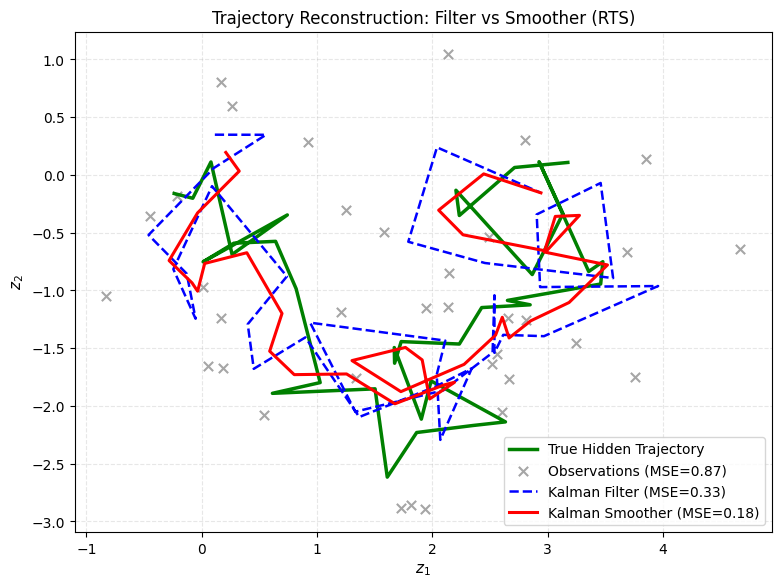

In [2]:
# 長い時系列の生成
N_long = 35
np.random.seed(42)
z_sim = [np.array([0.0, 0.0])]
x_sim = []

for _ in range(N_long):
    z_sim.append(A_mat @ z_sim[-1] + np.random.multivariate_normal([0, 0], Gamma_mat))
    x_sim.append(C_mat @ z_sim[-1] + np.random.multivariate_normal([0, 0], Sigma_mat))
z_sim = np.array(z_sim[1:])
x_sim = np.array(x_sim)

# フィルタとスムーザの実行
mu_f, V_f = kf.filter(x_sim)
mu_s, V_s = kf.smooth(x_sim)

# 二乗誤差 (MSE) の比較
mse_obs = np.mean(np.sum((x_sim - z_sim)**2, axis=1))
mse_filt = np.mean(np.sum((mu_f - z_sim)**2, axis=1))
mse_smooth = np.mean(np.sum((mu_s - z_sim)**2, axis=1))

print(f"Observation MSE:     {mse_obs:.4f}")
print(f"Kalman Filter MSE:   {mse_filt:.4f}")
print(f"Kalman Smoother MSE: {mse_smooth:.4f}")
assert mse_smooth < mse_filt < mse_obs # スムーザが最も誤差小

# プロット
fig, ax = plt.subplots(figsize=(9, 6.5))

ax.plot(z_sim[:, 0], z_sim[:, 1], 'g-', lw=2.5, label='True Hidden Trajectory')
ax.scatter(x_sim[:, 0], x_sim[:, 1], color='gray', marker='x', s=45, alpha=0.7, label=f'Observations (MSE={mse_obs:.2f})')
ax.plot(mu_f[:, 0], mu_f[:, 1], 'b--', lw=1.8, label=f'Kalman Filter (MSE={mse_filt:.2f})')
ax.plot(mu_s[:, 0], mu_s[:, 1], 'r-', lw=2.2, label=f'Kalman Smoother (MSE={mse_smooth:.2f})')

ax.set_title('Trajectory Reconstruction: Filter vs Smoother (RTS)', fontsize=12)
ax.set_xlabel('$z_1$', fontsize=11); ax.set_ylabel('$z_2$', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig13_kalman_filter_vs_smoother.png')
plt.show()